In [2]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib # Para salvar os normalizadores

In [3]:
def create_delta_data(local_data, time_step=0.07):
    """
    Carrega dados e calcula a variação de x e y, alinhando as colunas.
    Usa o método de fatiamento explícito de arrays.
    """
    # Carrega os dados
    dados_originais = pd.read_csv(local_data)

    # Extrai as colunas x e y para arrays numpy
    x = dados_originais["x(Wd,We)"].to_numpy()
    y = dados_originais["y(Wd,We)"].to_numpy()

    # Calcula a variação (derivada) usando fatiamento de array
    delta_x = (x[1:] - x[:-1]) / time_step
    delta_y = (y[1:] - y[:-1]) / time_step

    # Alinha as outras colunas, removendo a última linha para corresponder ao tamanho
    wd_alinhado = dados_originais['Wd'].iloc[:-1]
    we_alinhado = dados_originais['We'].iloc[:-1]
    wd_true_alinhado = dados_originais['Wd_true'].iloc[:-1]
    we_true_alinhado = dados_originais['We_true'].iloc[:-1]
    theta_alinhado = dados_originais['theta(Wd,We)'].iloc[:-1]
    
    # Cria o novo DataFrame com os dados alinhados
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'Wd_true': wd_true_alinhado,
        'We_true': we_true_alinhado,
        'theta(Wd,We)': theta_alinhado,
        'delta_x': delta_x,
        'delta_y': delta_y
    })

    # Exibe informações e retorna o DataFrame
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new

TrainData = create_delta_data("./Dados/DataSmoothSpline1.csv")
TestData = create_delta_data("./Dados/DataSmoothSpline3.csv")
ValData = create_delta_data("./Dados/DataSmoothSpline2.csv")


         Wd        We   Wd_true   We_true  theta(Wd,We)   delta_x  \
0  2.046979  2.067159  0.163271  0.093873      0.009711  0.053856   
1  2.058519  2.079836  0.242458  0.175944      0.010059  0.053875   
2  2.069982  2.092437  0.321637  0.258010      0.010406  0.053923   
3  2.081302  2.104891  0.400792  0.340061      0.010752  0.054014   
4  2.092419  2.117138  0.479896  0.422075      0.011096  0.054157   

        delta_y  
0 -7.137148e-13  
1 -8.564578e-13  
2 -7.137148e-13  
3 -7.137148e-13  
4 -8.596298e-13  
Shape do novo_df: (2145, 7)
         Wd        We   Wd_true   We_true  theta(Wd,We)   delta_x   delta_y
0  2.250967  2.289211  0.204149  0.077678      0.018082  0.055195  0.000491
1  2.246293  2.286558  0.283600  0.162385      0.018703  0.055214  0.000492
2  2.241624  2.283906  0.363042  0.247087      0.019323  0.055262  0.000492
3  2.236964  2.281260  0.442455  0.331776      0.019940  0.055352  0.000493
4  2.232324  2.278624  0.521806  0.416432      0.020554  0.055493  0.

In [4]:
# Define predictors and target
PREDICTORS = ["Wd", "We", "theta(Wd,We)"]
TARGET = ["delta_x", "delta_y"]
RESTRICTIONS = ["Wd_true", "We_true"]


Restrictions_data = TrainData[RESTRICTIONS].to_numpy()

print("\nShape de Restrictions_data:", Restrictions_data.shape)
print("Primeiras linhas de Restrictions_data:\n", Restrictions_data[:5])

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[TARGET].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[TARGET].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[TARGET].to_numpy()


x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(-1, 1))

print("\nAjustando os normalizadores (scalers) com os dados de treino...")
x_scaler.fit(train_x)
y_scaler.fit(train_y)

joblib.dump(x_scaler, 'x_scaler.gz')
joblib.dump(y_scaler, 'y_scaler.gz')
print("Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'")

# AGORA, TRANSFORME TODOS OS CONJUNTOS DE DADOS com os scalers já ajustados
train_x_norm = x_scaler.transform(train_x)
train_y_norm = y_scaler.transform(train_y)

x_val_norm = x_scaler.transform(x_val)
y_val_norm = y_scaler.transform(y_val)

x_test_norm = x_scaler.transform(x_test)
y_test_norm = y_scaler.transform(y_test)

#restric_norm = x_scaler.transform(Restrictions_data)
#print("\nShape de Restrictions_data normalizado:", restric_norm.shape)

print("\nShape de X_train depois da normalização:", train_x_norm.shape)
print("Primeiras linhas de X_train normalizado:\n", train_x_norm[:5])
print("\nPrimeiras linhas de y_train normalizado:\n", train_y_norm[:5])



Shape de Restrictions_data: (2145, 2)
Primeiras linhas de Restrictions_data:
 [[0.16327083 0.0938734 ]
 [0.24245778 0.17594412]
 [0.32163697 0.25801016]
 [0.40079243 0.34006069]
 [0.47989594 0.42207508]]
(2145, 3)

Ajustando os normalizadores (scalers) com os dados de treino...
Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'

Shape de X_train depois da normalização: (2145, 3)
Primeiras linhas de X_train normalizado:
 [[ 0.84617662  0.86253703 -0.17961437]
 [ 0.85097515  0.86788632 -0.17926799]
 [ 0.85574195  0.87320305 -0.17892204]
 [ 0.86044886  0.87845795 -0.17857727]
 [ 0.86507184  0.8836256  -0.17823484]]

Primeiras linhas de y_train normalizado:
 [[ 0.64850702 -0.05186337]
 [ 0.64874682 -0.05186337]
 [ 0.64937436 -0.05186337]
 [ 0.65054596 -0.05186337]
 [ 0.65239141 -0.05186337]]


In [5]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       y_scaler,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    #restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We
            #x1_km1 = train_x[:, 0]  # Wd
            #x2_km1 = train_x[:, 1]  # We
            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys_real  = ((R / L) * (x1_km1 - x2_km1)) 

            phys_real = phys_real.reshape((-1, 1))  # shape [N-1, 1]
            phys_norm = y_scaler.transform(phys_real)
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys_norm))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }
    if plot:
        for split, m in metrics.items():
            print(f"\n{split} Metrics:")
            for k, v in m.items():
                print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

In [6]:
def create_sequences(input_data, target_data, timesteps):
    """
    Cria sequências de dados para treinamento de RNN.

    Args:
        input_data (np.array): Dados de entrada (X), formato (samples, features).
        target_data (np.array): Dados de saída (Y), formato (samples, target_features).
        timesteps (int): O número de passos de tempo passados a serem considerados.

    Returns:
        X_seq (np.array): Dados de entrada sequenciais, formato (N, timesteps, features).
        Y_seq (np.array): Dados de saída correspondentes, formato (N, target_features).
    """
    X_seq, Y_seq = [], []
    
    # Itera sobre os dados, começando após o número de timesteps
    for i in range(timesteps, len(input_data)):
        # A sequência de entrada (X_seq) é a janela de dados de i-timesteps até i
        X_seq.append(input_data[i-timesteps:i])
        
        # O alvo (Y_seq) é o valor de saída no passo de tempo atual 'i'
        Y_seq.append(target_data[i])
    
    return np.array(X_seq), np.array(Y_seq)

FEATURES = 3 # Wd e We

In [7]:
TIME_STEPS = 3 # Usando apenas o passo atual para o modelo RNN
model_pirrn = keras.models.Sequential([
    keras.layers.SimpleRNN(15, return_sequences=False, input_shape=[TIME_STEPS, FEATURES], kernel_regularizer= keras.regularizers.l2(0)),
    keras.layers.Dense(2, use_bias= False)
])
train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, TIME_STEPS)
x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, TIME_STEPS)
x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, TIME_STEPS)
optimizer = keras.optimizers.Adam(learning_rate=0.01)
model_pirrn.compile(
    optimizer=optimizer,
    loss='mean_squared_error',  # Erro Quadrático Médio (MSE), padrão para regressão.
    metrics=['mean_absolute_error'] # Erro Absoluto Médio (MAE) como métrica adicional.
)
model_pirrn.summary()
#MSE TESTE 0.02434 

c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 15)             │           285 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315 (1.23 KB)

 Trainable params: 315 (1.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - loss: 1.3454 - mean_absolute_error: 0.9654 - val_loss: 0.4207 - val_mean_absolute_error: 0.5300
Epoch 2/10000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5510 - mean_absolute_error: 0.6168 - val_loss: 0.1759 - val_mean_absolute_error: 0.3358
Epoch 3/10000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.2358 - mean_absolute_error: 0.4023 - val_loss: 0.1111 - val_mean_absolute_error: 0.2427
Epoch 4/10000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1319 - mean_absolute_error: 0.2653 - val_loss: 0.1225 - val_mean_absolute_error: 0.2794
Epoch 5/10000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.1238 - mean_absolute_error: 0.2702 - val_loss: 0.1267 - val_mean_absolute_error: 0.2967
Epoch 6/10000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1150 - mean_absolute_error: 0.2666 - val_loss: 0.1097 - val_mean_absolute_error: 0.2648
Epoch 7/10000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0870 - mean_absolute_error: 0.2186 - 

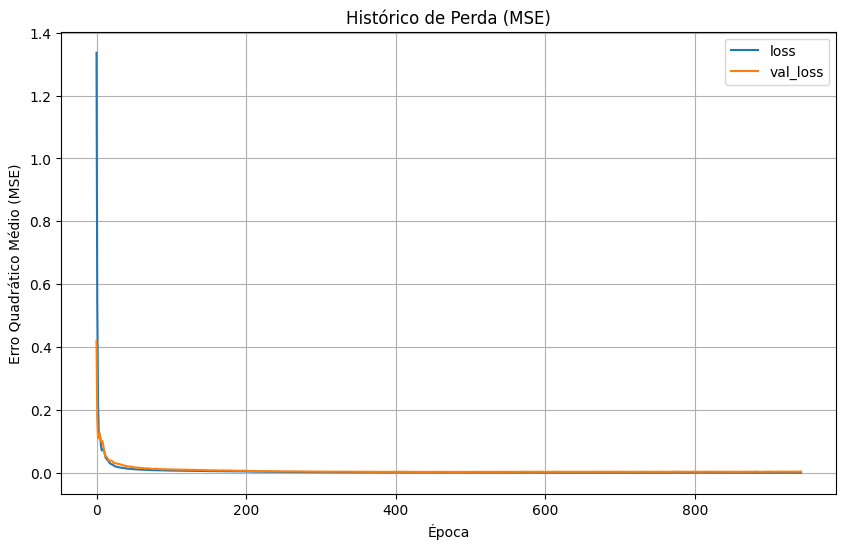

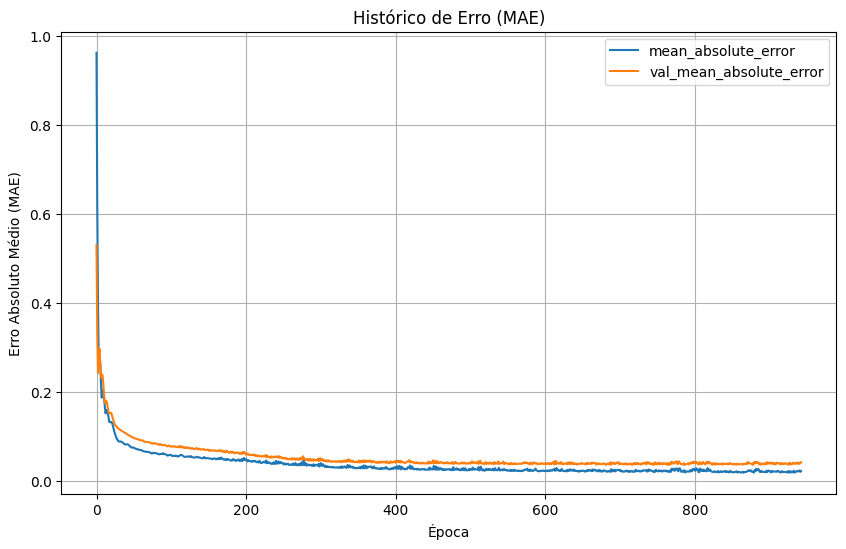

In [8]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', # Métrica a ser monitorada
    patience=500,        # Nº de épocas de espera por melhoria
    restore_best_weights=True # Restaura os pesos da melhor época
)

history = model_pirrn.fit(
    train_x_seq,
    train_y_seq,
    epochs=10000,  # Número máximo de épocas
    batch_size=len(x_test_seq), # Tamanho do lote (mini-batch)
    validation_data=(x_val_seq, y_val_seq), # Dados para monitorar overfitting
    callbacks=[early_stopping], # Lista de callbacks a serem usados
    verbose=1 # Mostra a barra de progresso
)


# --------------------------------------------------------------------------
## PASSO 3: Visualizar os Resultados 📊
# --------------------------------------------------------------------------
# Usamos o objeto 'history' para plotar as curvas de aprendizado.

print("\n--- Gerando gráficos do histórico de treinamento ---")
history_df = pd.DataFrame(history.history)

# Gráfico da Perda (MSE)
history_df.loc[:, ['loss', 'val_loss']].plot(
    title='Histórico de Perda (MSE)',
    figsize=(10, 6),
    grid=True
)
plt.xlabel("Época")
plt.ylabel("Erro Quadrático Médio (MSE)")
plt.show()

# Gráfico da Métrica (MAE)
history_df.loc[:, ['mean_absolute_error', 'val_mean_absolute_error']].plot(
    title='Histórico de Erro (MAE)',
    figsize=(10, 6),
    grid=True
)
plt.xlabel("Época")
plt.ylabel("Erro Absoluto Médio (MAE)")
plt.show()


         Wd        We   Wd_true   We_true  theta(Wd,We)   delta_x  \
0  2.046979  2.067159  0.163271  0.093873      0.009711  0.053856   
1  2.058519  2.079836  0.242458  0.175944      0.010059  0.053875   
2  2.069982  2.092437  0.321637  0.258010      0.010406  0.053923   
3  2.081302  2.104891  0.400792  0.340061      0.010752  0.054014   
4  2.092419  2.117138  0.479896  0.422075      0.011096  0.054157   

        delta_y  
0 -7.137148e-13  
1 -8.564578e-13  
2 -7.137148e-13  
3 -7.137148e-13  
4 -8.596298e-13  
Shape do novo_df: (2145, 7)
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE Total da Trajetória Reconstruída: 0.001342
  - MSE em X: 0.002433
  - MSE em Y: 0.0002503


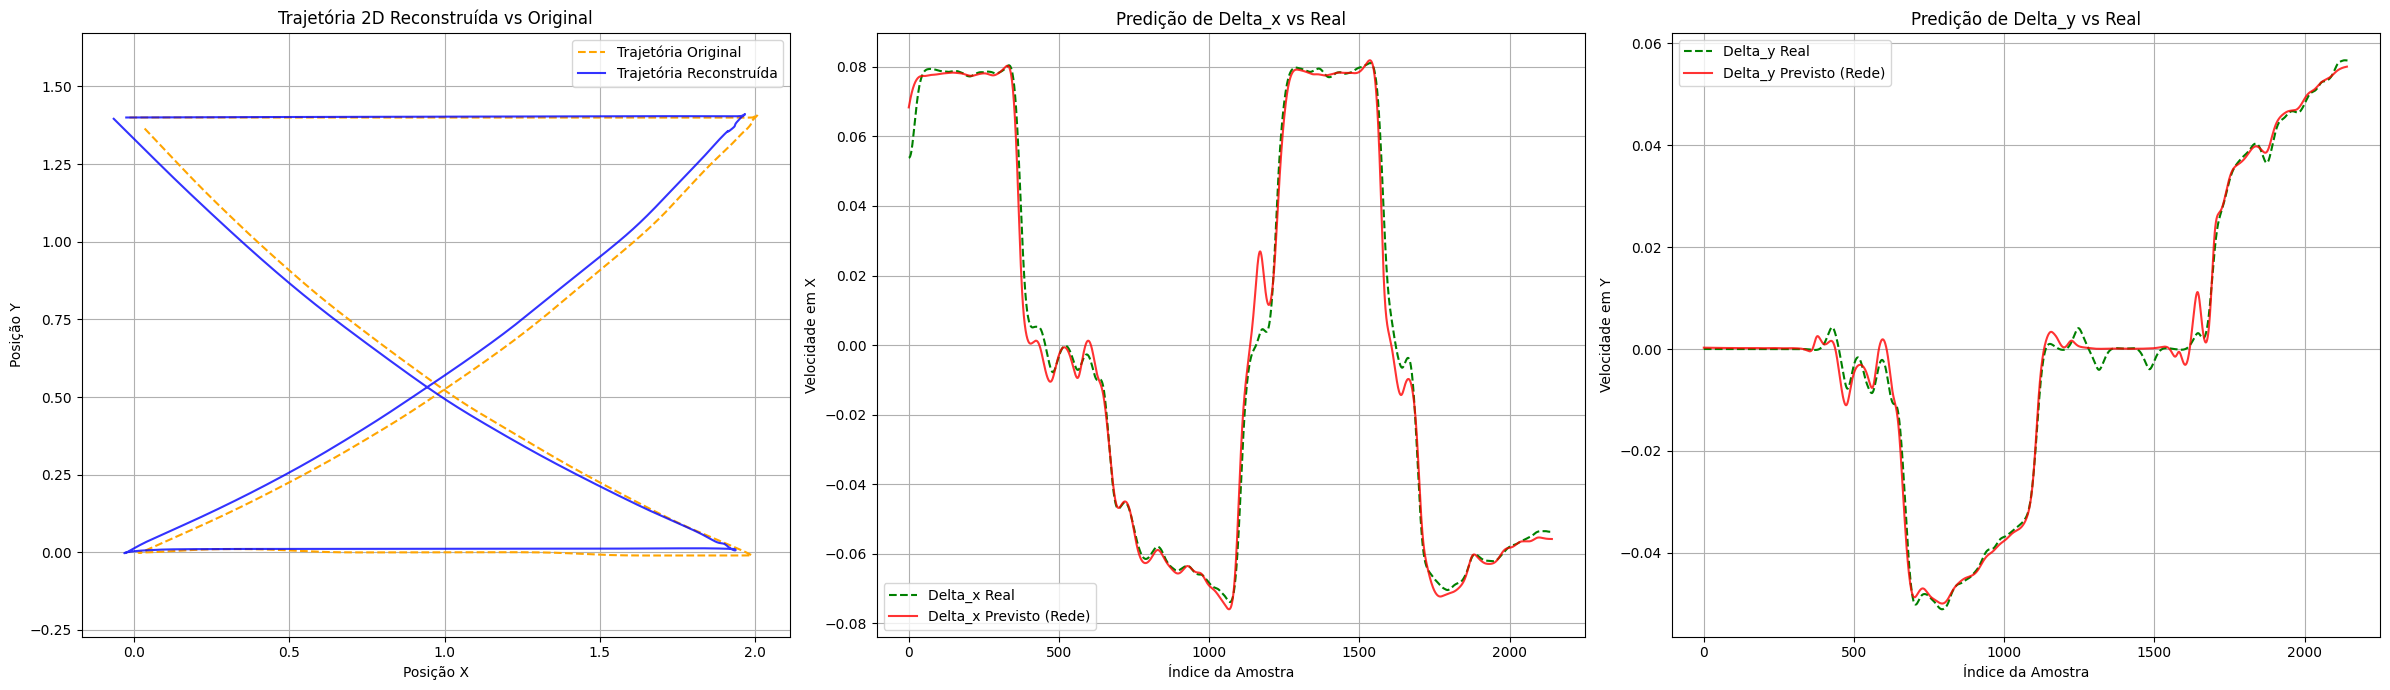

         Wd        We   Wd_true   We_true  theta(Wd,We)   delta_x   delta_y
0  1.866241  1.950911  0.118729 -0.110797      0.036942  0.045499  0.002479
1  1.870389  1.957288  0.187222 -0.030969      0.037438  0.045516  0.002479
2  1.874468  1.963593  0.255708  0.048863      0.037933  0.045561  0.002480
3  1.878425  1.969766  0.324177  0.128705      0.038424  0.045646  0.002481
4  1.882225  1.975761  0.392606  0.208559      0.038905  0.045779  0.002483
Shape do novo_df: (1325, 7)
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MSE Total da Trajetória Reconstruída: 0.001248
  - MSE em X: 0.002326
  - MSE em Y: 0.0001701


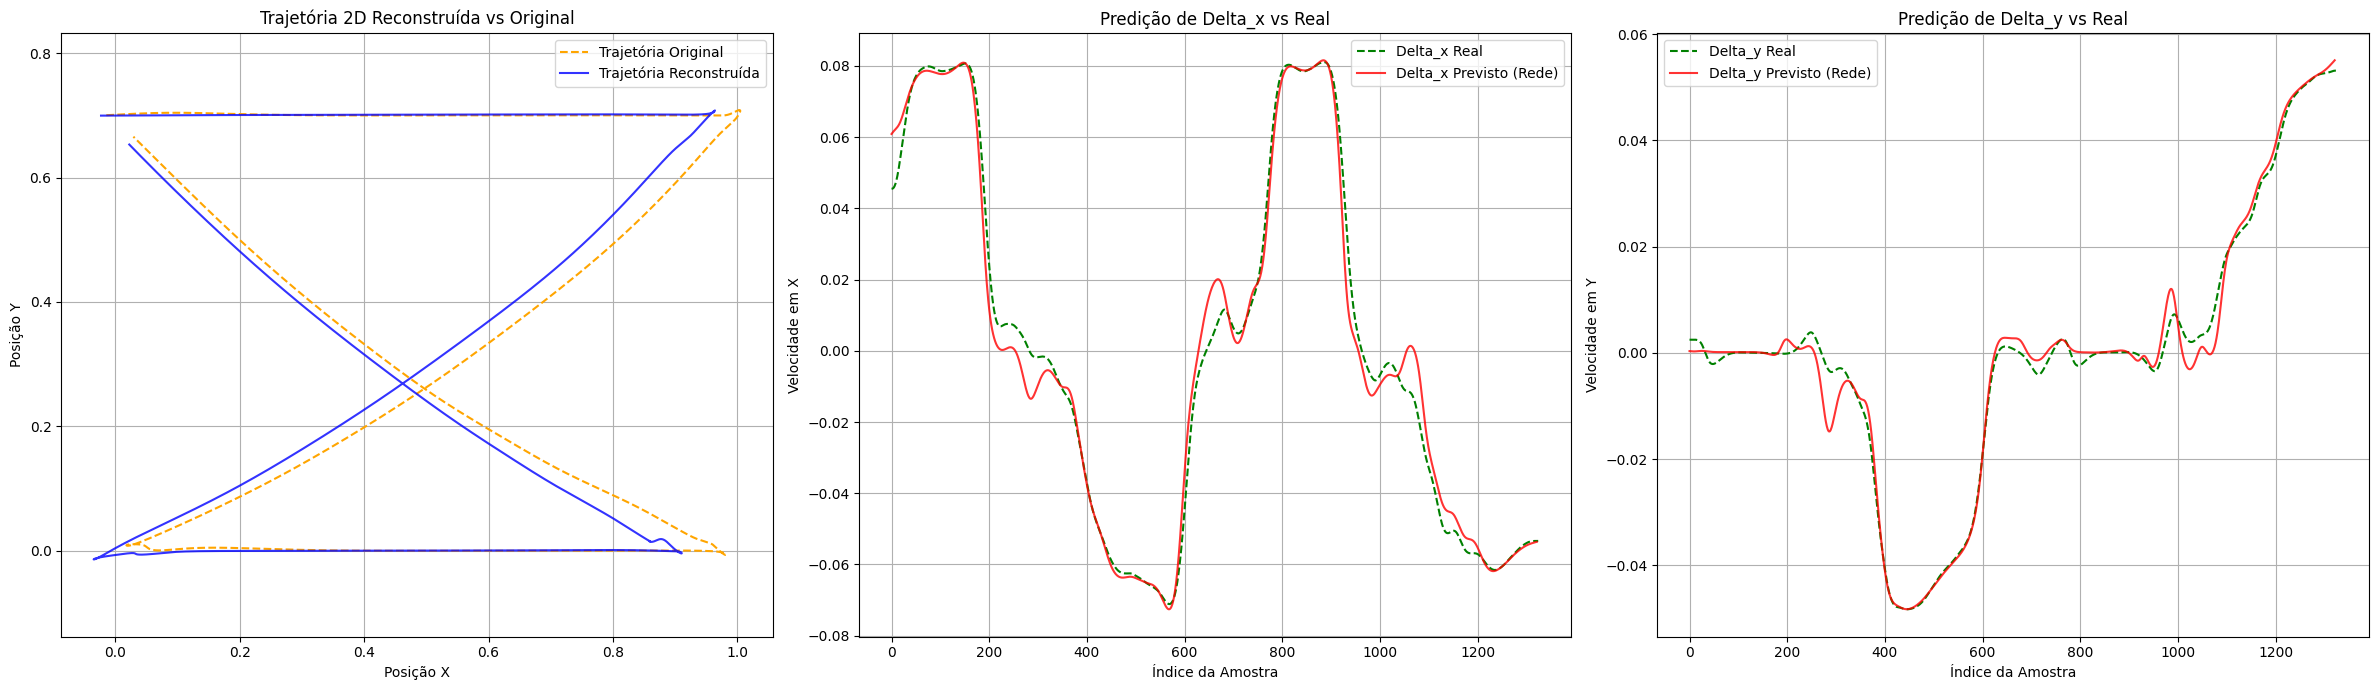

         Wd        We   Wd_true   We_true  theta(Wd,We)   delta_x   delta_y
0  2.250967  2.289211  0.204149  0.077678      0.018082  0.055195  0.000491
1  2.246293  2.286558  0.283600  0.162385      0.018703  0.055214  0.000492
2  2.241624  2.283906  0.363042  0.247087      0.019323  0.055262  0.000492
3  2.236964  2.281260  0.442455  0.331776      0.019940  0.055352  0.000493
4  2.232324  2.278624  0.521806  0.416432      0.020554  0.055493  0.000495
Shape do novo_df: (2026, 7)
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE Total da Trajetória Reconstruída: 0.007305
  - MSE em X: 0.01352
  - MSE em Y: 0.001086


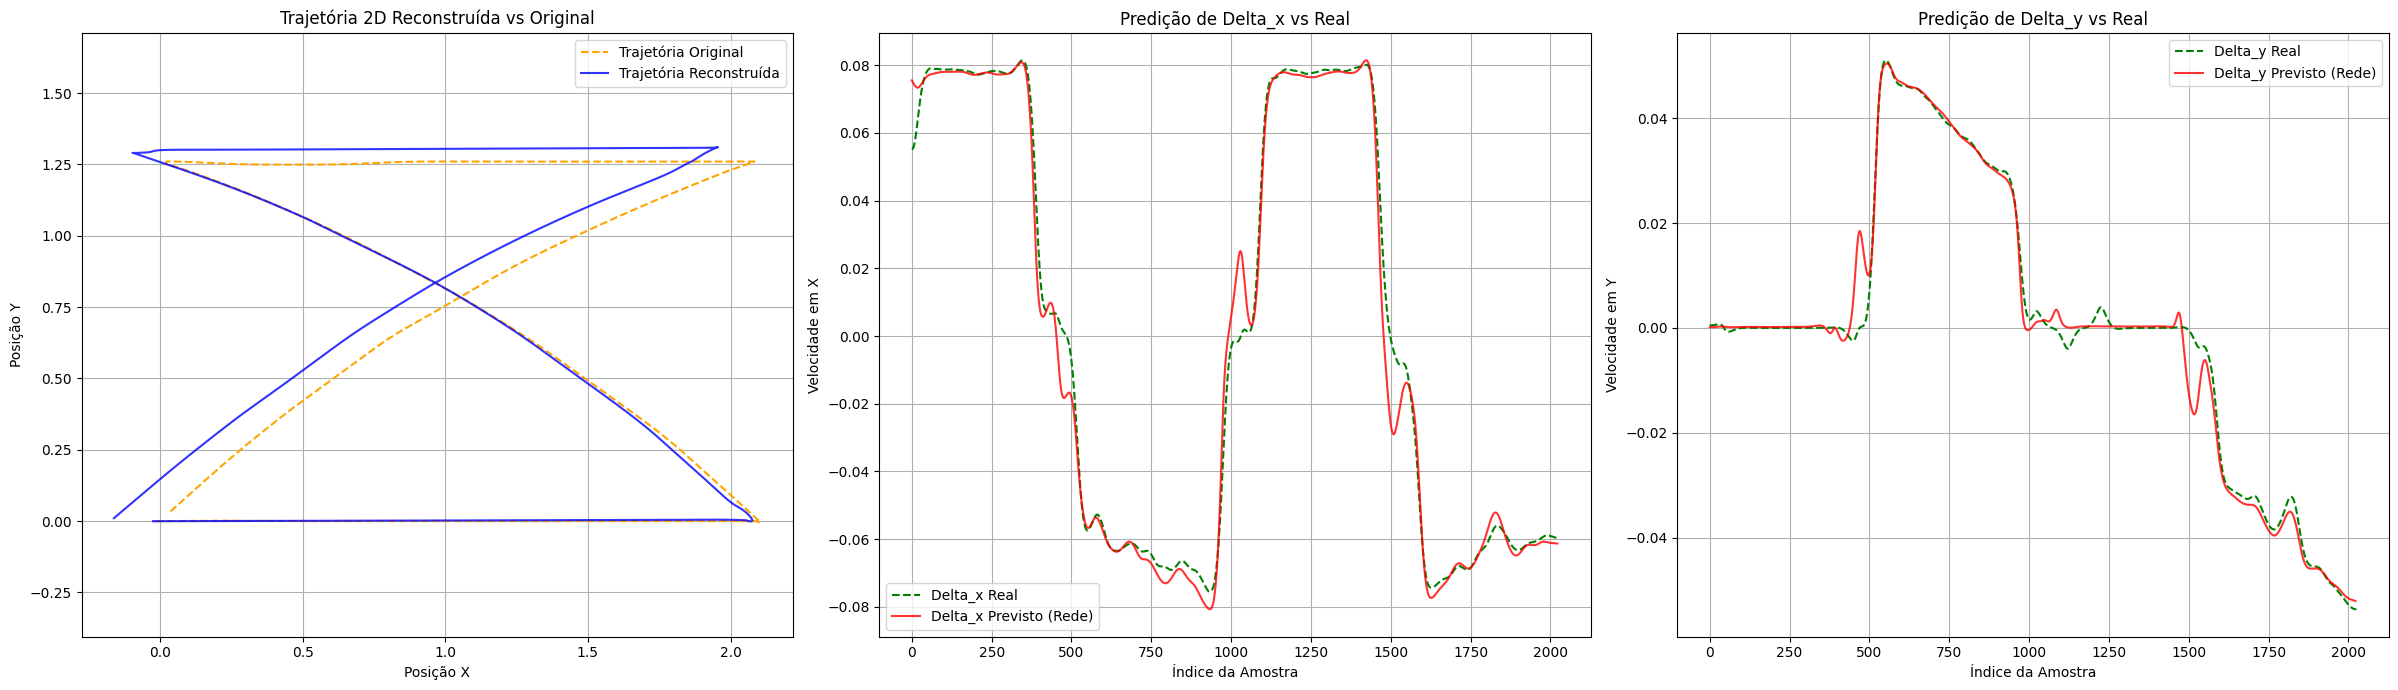

0.007304907015934053

In [9]:
def Reconstruir_Trajetoria(model, inputs_norm, local_data_original, x_scaler, y_scaler, time_step=0.07):
    """
    Reconstrói a trajetória (x, y) a partir da previsão de suas derivadas,
    calcula o MSE e plota os resultados.
    """
    # 1. Obter os dados reais das derivadas para comparação
    df_reais = create_delta_data(local_data_original)
    delta_x_real = df_reais[["delta_x"]].to_numpy()
    delta_y_real = df_reais[["delta_y"]].to_numpy()

    # 2. Fazer predições com o modelo
    # A saída do modelo terá duas colunas: [delta_x_norm, delta_y_norm]
    Y_norm_pred = model.predict(inputs_norm)
    
    # 3. Denormalizar as previsões para a escala real
    # y_scaler foi ajustado em [delta_x, delta_y], então ele denormaliza ambos.
    Y_pred_real = y_scaler.inverse_transform(Y_norm_pred)
    delta_x_pred = Y_pred_real[:, 0]
    delta_y_pred = Y_pred_real[:, 1]
    
    # 4. Carregar os dados originais da trajetória (x, y)
    DataOrigi = pd.read_csv(local_data_original)
    X_true = DataOrigi["x(Wd,We)"].to_numpy()
    Y_true = DataOrigi["y(Wd,We)"].to_numpy()

    # 5. Reconstruir a trajetória por integração de Euler
    x_reconstruido = np.zeros_like(delta_x_pred)
    y_reconstruido = np.zeros_like(delta_y_pred)
    
    # Condição inicial: usa o primeiro ponto real da trajetória
    x_reconstruido[0] = X_true[0] + delta_x_pred[0] * time_step
    y_reconstruido[0] = Y_true[0] + delta_y_pred[0] * time_step
    
    for i in range(1, len(delta_x_pred)):
        x_reconstruido[i] = x_reconstruido[i-1] + delta_x_pred[i] * time_step
        y_reconstruido[i] = y_reconstruido[i-1] + delta_y_pred[i] * time_step

    # 6. Alinhar os dados verdadeiros para o cálculo do erro
    offset = len(X_true) - len(x_reconstruido)
    X_true_alinhado = X_true[offset:]
    Y_true_alinhado = Y_true[offset:]

    # 7. Calcular o erro MSE para x e y
    mse_x = np.mean(np.square(X_true_alinhado - x_reconstruido))
    mse_y = np.mean(np.square(Y_true_alinhado - y_reconstruido))
    mse_total = (mse_x + mse_y) / 2 # Média dos erros
    
    print(f"MSE Total da Trajetória Reconstruída: {mse_total:.4g}")
    print(f"  - MSE em X: {mse_x:.4g}")
    print(f"  - MSE em Y: {mse_y:.4g}")

    # ---------- PLOTS ----------
    fig, axs = plt.subplots(1, 3, figsize=(24, 7))

    # Gráfico 1: Trajetória 2D (x vs y)
    axs[0].plot(X_true_alinhado, Y_true_alinhado, label='Trajetória Original', color='orange', linestyle='--')
    axs[0].plot(x_reconstruido, y_reconstruido, label='Trajetória Reconstruída', color='blue', alpha=0.8)
    axs[0].set_xlabel('Posição X')
    axs[0].set_ylabel('Posição Y')
    axs[0].set_title('Trajetória 2D Reconstruída vs Original')
    axs[0].legend()
    axs[0].grid(True)
    axs[0].axis('equal')

    # Gráfico 2: Comparação de delta_x
    axs[1].plot(delta_x_real, label='Delta_x Real', color='green', linestyle='--')
    axs[1].plot(delta_x_pred, label='Delta_x Previsto (Rede)', color='red', alpha=0.8)
    axs[1].set_xlabel('Índice da Amostra')
    axs[1].set_ylabel('Velocidade em X')
    axs[1].set_title('Predição de Delta_x vs Real')
    axs[1].legend()
    axs[1].grid(True)
    
    # Gráfico 3: Comparação de delta_y
    axs[2].plot(delta_y_real, label='Delta_y Real', color='green', linestyle='--')
    axs[2].plot(delta_y_pred, label='Delta_y Previsto (Rede)', color='red', alpha=0.8)
    axs[2].set_xlabel('Índice da Amostra')
    axs[2].set_ylabel('Velocidade em Y')
    axs[2].set_title('Predição de Delta_y vs Real')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()
    # ---------------------------

    return mse_total



Reconstruir_Trajetoria(model_pirrn, train_x_seq, "./Dados/DataSmoothSpline1.csv", x_scaler,y_scaler)
Reconstruir_Trajetoria(model_pirrn, x_val_seq, "./Dados/DataSmoothSpline2.csv", x_scaler,y_scaler)
Reconstruir_Trajetoria(model_pirrn, x_test_seq, "./Dados/DataSmoothSpline3.csv",x_scaler, y_scaler)

In [23]:
Dataset_teste = pd.read_csv("./Dados/DataSmoothSpline3.csv")
print(Dataset_teste.shape)
Theta_pred = pd.read_csv("theta_teste.csv")
print(Theta_pred)
New_dataset_teste = Dataset_teste.iloc[:-4]
print(New_dataset_teste.shape)
New_dataset_teste['theta(Wd,We)'] = Theta_pred.iloc[:, 1].values
print(New_dataset_teste)
New_dataset_teste.to_csv("DatasetTreinoPrev.csv", index=False)


(2027, 9)
      Unnamed: 0         0
0              0  0.017844
1              1  0.017594
2              2  0.017331
3              3  0.017054
4              4  0.016764
...          ...       ...
2018        2018  0.408157
2019        2019  0.408907
2020        2020  0.409706
2021        2021  0.410554
2022        2022  0.411447

[2023 rows x 2 columns]
(2023, 9)
      Unnamed: 0  x(Wd,We)  y(Wd,We)  theta(Wd,We)   Wd_true   We_true  \
0              0 -0.029553 -0.000344      0.017844  0.204149  0.077678   
1              1 -0.025690 -0.000310      0.017594  0.283600  0.162385   
2              2 -0.021825 -0.000275      0.017331  0.363042  0.247087   
3              3 -0.017956 -0.000241      0.017054  0.442455  0.331776   
4              4 -0.014082 -0.000206      0.016764  0.521806  0.416432   
...          ...       ...       ...           ...       ...       ...   
2018        2018  0.066287  0.060086      0.408157 -2.337178 -2.357735   
2019        2019  0.062113  0.056332   

C:\Users\João Vitor\AppData\Local\Temp\ipykernel_24188\1565326452.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  New_dataset_teste['theta(Wd,We)'] = Theta_pred.iloc[:, 1].values


         Wd        We   Wd_true   We_true  theta(Wd,We)   delta_x   delta_y
0  2.250967  2.289211  0.204149  0.077678      0.017844  0.055195  0.000491
1  2.246293  2.286558  0.283600  0.162385      0.017594  0.055214  0.000492
2  2.241624  2.283906  0.363042  0.247087      0.017331  0.055262  0.000492
3  2.236964  2.281260  0.442455  0.331776      0.017054  0.055352  0.000493
4  2.232324  2.278624  0.521806  0.416432      0.016764  0.055493  0.000495
Shape do novo_df: (2022, 7)
         Wd        We   Wd_true   We_true  theta(Wd,We)   delta_x   delta_y
0  2.250967  2.289211  0.204149  0.077678      0.017844  0.055195  0.000491
1  2.246293  2.286558  0.283600  0.162385      0.017594  0.055214  0.000492
2  2.241624  2.283906  0.363042  0.247087      0.017331  0.055262  0.000492
3  2.236964  2.281260  0.442455  0.331776      0.017054  0.055352  0.000493
4  2.232324  2.278624  0.521806  0.416432      0.016764  0.055493  0.000495
Shape do novo_df: (2022, 7)
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

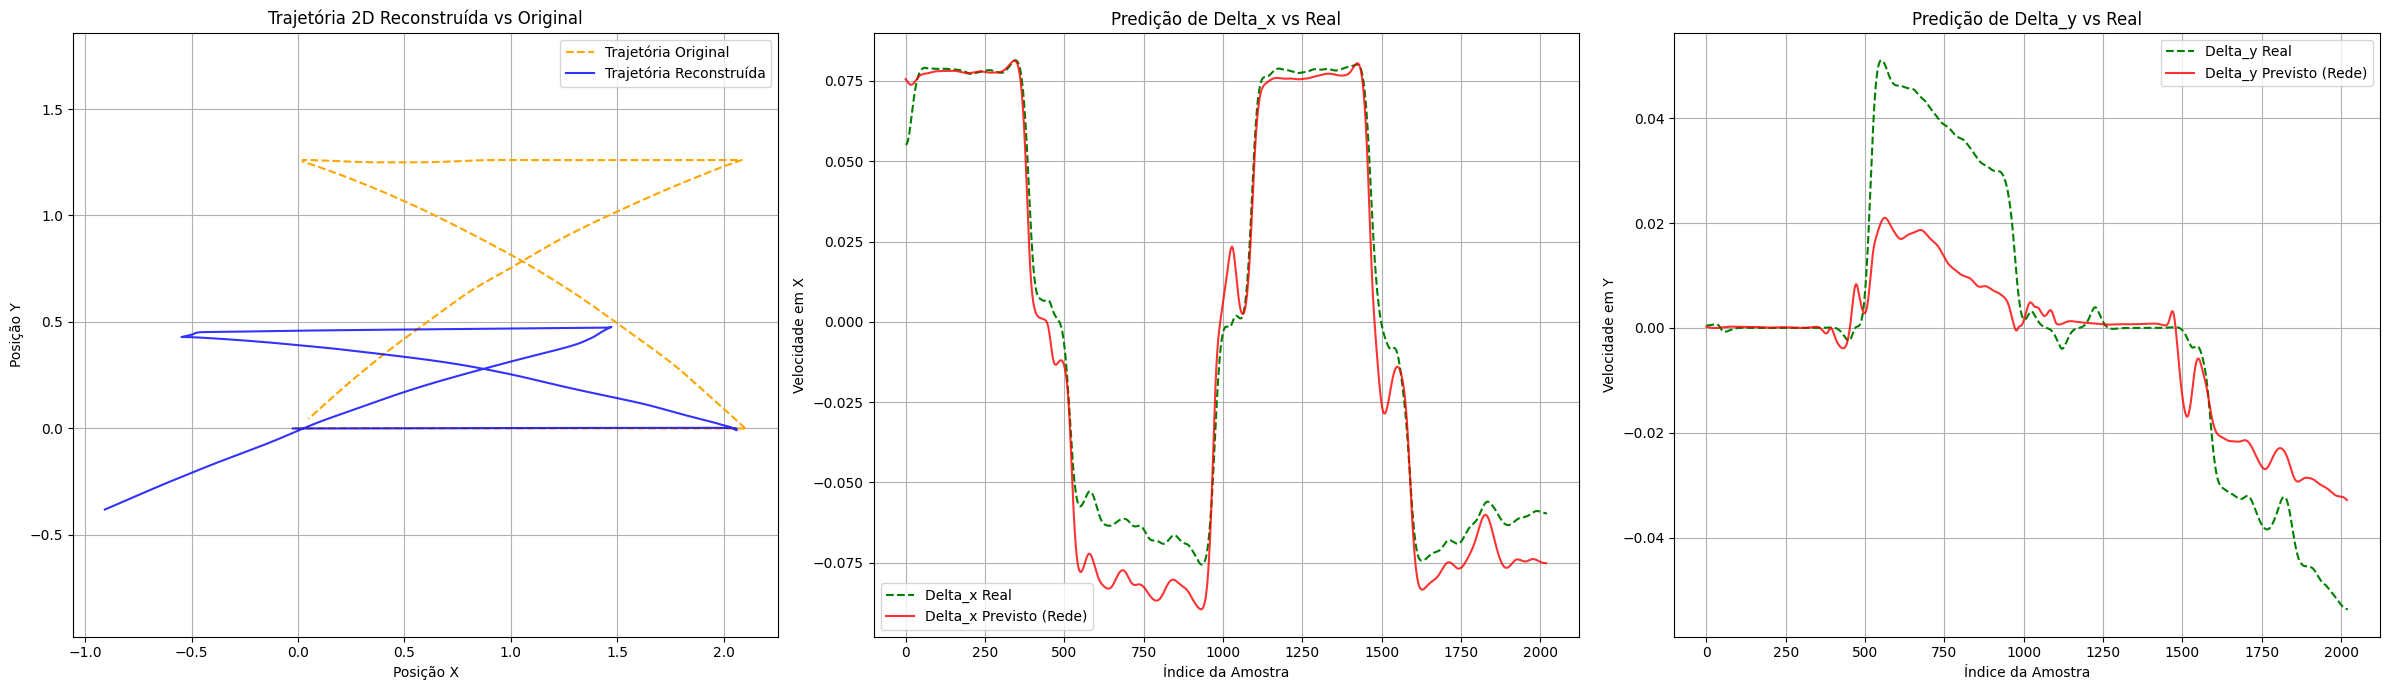

0.3082795202409133

In [37]:
# Definição das entradas e saídas
PREDICTORS = ["Wd", "We", "theta(Wd,We)"] # Inclui theta como entrada
TARGETS = ["delta_x", "delta_y"]
TIME_STEPS = 3

# Carrega os dados de teste originais e as previsões de theta da Rede 1
TestData_original = create_delta_data("DatasetTreinoPrev.csv")

x_test_rnn = TestData_original[PREDICTORS].to_numpy()
y_test_rnn = TestData_original[TARGET].to_numpy()


x_test_norm_rnn = x_scaler.transform(x_test_rnn)
y_test_norm_rnn = y_scaler.transform(y_test_rnn)

x_test_seq_rnn, y_test_seq_rnn = create_sequences(x_test_norm_rnn, y_test_norm_rnn, TIME_STEPS)
Reconstruir_Trajetoria(model_pirrn, x_test_seq_rnn, "DatasetTreinoPrev.csv",x_scaler, y_scaler)